# Assignment 7: Exploring Specialized Neural Network Architectures
# Building Convolutional Neural Networks for Image Classification

**Name:** Drake DelValle

---

## Setup: Install and Load Libraries

In [6]:
pip install tensorflow matplotlib numpy pandas


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist

print("Libraries loaded successfully!")

Libraries loaded successfully!


## Load and Explore MNIST Dataset

In [2]:
# Load MNIST dataset
print("Loading MNIST dataset...")
(X_train, y_train), (X_test, y_test) = mnist.load_data()


print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Number of classes: {len(np.unique(y_train))}")
print(f"Class labels: {np.unique(y_train)}")

Loading MNIST dataset...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training set shape: (60000, 28, 28)
Test set shape: (10000, 28, 28)
Number of classes: 10
Class labels: [0 1 2 3 4 5 6 7 8 9]


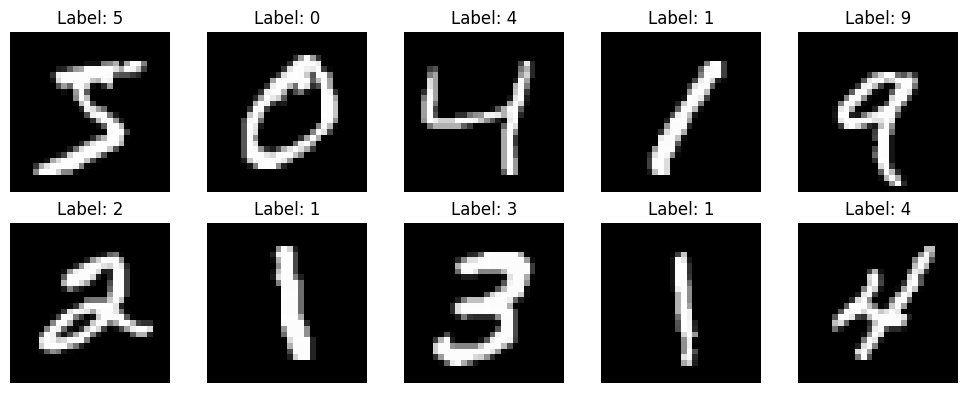

In [3]:
# Visualize sample images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## Prepare Data for CNN

In [7]:
# Reshape to add channel dimension (samples, height, width, channels)
X_train_cnn = X_train.reshape(-1, 28, 28, 1).astype('float32')
X_test_cnn = X_test.reshape(-1, 28, 28, 1).astype('float32')

# Normalize pixel values to 0-1 range
X_train_cnn = X_train_cnn / 255.0
X_test_cnn = X_test_cnn / 255.0

print("\n" + "="*80)
print("DATA PREPARED FOR CNN")
print("="*80)
print(f"Training data shape: {X_train_cnn.shape}")
print(f"Test data shape: {X_test_cnn.shape}")
print(f"Pixel value range: [{X_train_cnn.min():.1f}, {X_train_cnn.max():.1f}]")
print("="*80)


DATA PREPARED FOR CNN
Training data shape: (60000, 28, 28, 1)
Test data shape: (10000, 28, 28, 1)
Pixel value range: [0.0, 1.0]


---
## Step 2: Build and Train a Baseline CNN

In [8]:
from tensorflow import keras
from tensorflow.keras import layers
# TODO: Build your baseline CNN here
# Architecture:
# - Conv2D layer: 32 filters, 3x3 kernel, ReLU activation, input_shape=(28, 28, 1)
# - MaxPooling2D: 2x2 pool size
# - Conv2D layer: 64 filters, 3x3 kernel, ReLU activation
# - MaxPooling2D: 2x2 pool size
# - Flatten layer
# - Dense layer: 128 nodes, ReLU activation
# - Output layer: 10 nodes (digits 0-9), softmax activation

baseline_cnn = keras.Sequential([
    # TODO: Add layers here
    # First convolutional block
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    # Second convolutional block
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    # Flatten and dense layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# TODO: Compile the model
# Use Adam optimizer and sparse_categorical_crossentropy loss

baseline_cnn.compile(
    optimizer= 'adam',
    loss= 'sparse_categorical_crossentropy',
    metrics= ['accuracy']
)


# Display model architecture
baseline_cnn.summary()

c:\Users\dddva\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Record training time
print("\nTraining baseline CNN...")
start_time = time.time()

# TODO: Fit the model and store history
history = baseline_cnn.fit(X_train, y_train, epochs=10, validation_split=0.2, verbose=0)  # Replace with actual model fitting

baseline_time = time.time() - start_time

# TODO: Evaluate on test set
baseline_test_loss, baseline_test_acc = baseline_cnn.evaluate(X_test, y_test, verbose=0)  # Replace with actual evaluation

print("\n" + "="*80)
print("BASELINE CNN RESULTS")
print("="*80)
# Print final training accuracy, validation accuracy, test accuracy, training time
print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Test Accuracy: {baseline_test_acc:.4f}")
print(f"Training Time: {baseline_time:.2f} seconds")
print("="*80)


Training baseline CNN...

BASELINE CNN RESULTS
Final Training Accuracy: 0.9966
Final Validation Accuracy: 0.9867
Test Accuracy: 0.9877
Training Time: 148.94 seconds


---
## Step 3: Experiment with Filter Counts

In [11]:
# TODO: Build and train CNN with FEWER filters (16, 32)
# Keep all other architecture elements the same as baseline

fewer_filters_model = keras.Sequential([
    keras.layers.Conv2D(16, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Conv2D(32, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

print("Training CNN with fewer filters (16, 32)...")
# TODO: Build, compile, and train model

fewer_filters_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

time_start = time.time()
history_fewer = fewer_filters_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)
time_end = time.time()
# Record validation accuracy

training_time_fewer = time_end - time_start
print(f"\nTraining with fewer filters completed in {training_time_fewer:.2f} seconds")

# Evaluate on test set
test_loss, test_accuracy = fewer_filters_model.evaluate(X_test, y_test, verbose=0)

print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

Training CNN with fewer filters (16, 32)...
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.8876 - loss: 1.1912 - val_accuracy: 0.9583 - val_loss: 0.1606
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9685 - loss: 0.1111 - val_accuracy: 0.9705 - val_loss: 0.1126
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9803 - loss: 0.0650 - val_accuracy: 0.9762 - val_loss: 0.0947
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.9860 - loss: 0.0454 - val_accuracy: 0.9737 - val_loss: 0.0971
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9891 - loss: 0.0331 - val_accuracy: 0.9805 - val_loss: 0.0759
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.9898 - loss: 0.0296 - val_accuracy: 0.9818 - val_loss: 0.0804
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9933 - loss: 0.0190 - val_accuracy: 0.9803 - val_loss: 0.0800
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step

In [12]:
# TODO: Build and train CNN with MORE filters (64, 128)
# Keep all other architecture elements the same as baseline

more_filters_model = keras.Sequential([
    keras.layers.Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Conv2D(128, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

print("Training CNN with more filters (64, 128)...")
# TODO: Build, compile, and train model

more_filters_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

time_start = time.time()
history_more = more_filters_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)
time_end = time.time()

# Record validation accuracy

training_time_more = time_end - time_start
print(f"\nTraining with more filters completed in {training_time_more:.2f} seconds")
# Evaluate on test set
test_loss, test_accuracy = more_filters_model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

c:\Users\dddva\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training CNN with more filters (64, 128)...
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 22s 48ms/step - accuracy: 0.9220 - loss: 1.1213 - val_accuracy: 0.9788 - val_loss: 0.0697
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 48ms/step - accuracy: 0.9820 - loss: 0.0574 - val_accuracy: 0.9806 - val_loss: 0.0662
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 19s 51ms/step - accuracy: 0.9882 - loss: 0.0370 - val_accuracy: 0.9835 - val_loss: 0.0603
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 19s 50ms/step - accuracy: 0.9902 - loss: 0.0296 - val_accuracy: 0.9852 - val_loss: 0.0591
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 19s 50ms/step - accuracy: 0.9927 - loss: 0.0216 - val_accuracy: 0.9850 - val_loss: 0.0674
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 48ms/step - accuracy: 0.9927 - loss: 0.0206 - val_accuracy: 0.9852 - val_loss: 0.0674
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.9950 - loss: 0.0144 - val_accuracy: 0.9857 - val_loss: 0.0653
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 47

### Analysis: Filter Count Effects

**TODO: Write 2-3 sentences answering:**
- How does increasing filter count affect performance?
- At what point do you see diminishing returns or overfitting?

Increasing the filter count improved accuracy, but the improvement was modest compared with the extra training cost. The fewer-filter model reached 0.9797 test accuracy in 64.89 seconds, the baseline model reached 0.9877 in 148.94 seconds, and the larger 64/128-filter model reached 0.9886 in 185.73 seconds, which suggests that more filters help the CNN learn richer visual features but also make training much slower.

The clearest point of diminishing returns appears when moving from the baseline model to the larger filter model, because test accuracy increases by only 0.0009 while training time rises noticeably. There is only mild evidence of overfitting, since the larger model’s training accuracy becomes very high while validation and test performance improve only slightly, so the main issue here is diminishing returns more than severe overfitting.

---
## Step 4: Experiment with Kernel Sizes

In [14]:
# TODO: Build and train CNN with MEDIUM kernels (5x5 for both layers)
# Keep filter counts at baseline (32, 64)

print("Training CNN with 5x5 kernels...")
# TODO: Build, compile, and train model
medium_kernels_model = keras.Sequential([
    layers.Conv2D(32, (5, 5), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (5, 5), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

medium_kernels_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

time_start = time.time()
history_medium = medium_kernels_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)
time_end = time.time()

# Record validation accuracy
training_time_larger = time_end - time_start
print(f"\nTraining with medium kernels completed in {training_time_larger:.2f} seconds")
# Evaluate on test set
test_loss, test_accuracy = medium_kernels_model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

Training CNN with 5x5 kernels...
Epoch 1/10


c:\Users\dddva\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.8913 - loss: 0.9782 - val_accuracy: 0.9663 - val_loss: 0.1083
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.9770 - loss: 0.0750 - val_accuracy: 0.9791 - val_loss: 0.0714
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.9862 - loss: 0.0446 - val_accuracy: 0.9780 - val_loss: 0.0755
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9911 - loss: 0.0285 - val_accuracy: 0.9847 - val_loss: 0.0523
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9929 - loss: 0.0231 - val_accuracy: 0.9827 - val_loss: 0.0631
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9938 - loss: 0.0195 - val_accuracy: 0.9847 - val_loss: 0.0603
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.9939 - loss: 0.0180 - val_accuracy: 0.9849 - val_loss: 0.0623
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9937 - loss: 0.0183 - val_accuracy: 0.98

In [16]:
# TODO: Build and train CNN with MIXED kernels (5x5 first layer, 3x3 second layer)
# Keep filter counts at baseline (32, 64)

mixed_kernels_model = keras.Sequential([
    layers.Conv2D(32, (5, 5), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

print("Training CNN with mixed kernels (5x5, 3x3)...")
# TODO: Build, compile, and train model

mixed_kernels_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

time_start = time.time()
history_mixed = mixed_kernels_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)
# Record validation accuracy

time_end = time.time()
training_time_mixed = time_end - time_start
print(f"\nTraining with mixed kernels completed in {training_time_mixed:.2f} seconds")

# Evaluate on test set
test_loss, test_accuracy = mixed_kernels_model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

Training CNN with mixed kernels (5x5, 3x3)...
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.9156 - loss: 0.7419 - val_accuracy: 0.9730 - val_loss: 0.0878
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9806 - loss: 0.0630 - val_accuracy: 0.9795 - val_loss: 0.0686
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9877 - loss: 0.0387 - val_accuracy: 0.9831 - val_loss: 0.0616
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9910 - loss: 0.0282 - val_accuracy: 0.9847 - val_loss: 0.0556
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9926 - loss: 0.0222 - val_accuracy: 0.9850 - val_loss: 0.0607
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9937 - loss: 0.0180 - val_accuracy: 0.9822 - val_loss: 0.0754
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9941 - loss: 0.0173 - val_accuracy: 0.9805 - val_loss: 0.0816
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/ste

### Analysis: Kernel Size Effects

**TODO: Write 2-3 sentences answering:**
- How does kernel size affect what the network learns?
- Which kernel configuration performed best and why might that be?

Kernel size changes the scale of the visual patterns the CNN can detect: larger 5x5 kernels look at a wider region of the image at once, which helps capture broader digit shapes, while smaller 3x3 kernels focus more precisely on local details such as edges and corners. In the step 4 experiments, the mixed kernel configuration performed best, reaching 0.9851 test accuracy with 0.0623 test loss, which suggests that using a 5x5 kernel first to capture larger stroke structure and a 3x3 kernel later to refine smaller features gave the network a better balance than using one kernel size everywhere.


---
## Step 5: Train Your Best Architecture and Visualize Learning

In [31]:
# TODO: Based on your experiments, build your best-performing CNN architecture
# Train for 15 epochs with 20% validation split

#  Best performing CNN was with FEWER filters (16, 32)

print("Training best CNN architecture...")
start_time = time.time()

#  Best performing CNN was with FEWER filters (16, 32)

best_cnn_model = keras.Sequential([
    keras.layers.Conv2D(16, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Conv2D(32, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

print("Training CNN with fewer filters (16, 32)...")


# TODO: Build, compile, and train your best model
best_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Store the training history

time_start = time.time()
history_best = best_cnn_model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)
time_end = time.time()

# Record validation accuracy

best_cnn_time = time.time() - start_time
print(f"\nTraining best CNN architecture completed in {best_cnn_time:.2f} seconds")

# TODO: Evaluate on test set
test_loss, test_accuracy_best = best_cnn_model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy_best:.4f}")
print(f"Test Loss: {test_loss:.4f}")



Training best CNN architecture...
Training CNN with fewer filters (16, 32)...
Epoch 1/15


c:\Users\dddva\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8929 - loss: 1.1669 - val_accuracy: 0.9589 - val_loss: 0.1687
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9679 - loss: 0.1160 - val_accuracy: 0.9704 - val_loss: 0.1214
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9796 - loss: 0.0688 - val_accuracy: 0.9740 - val_loss: 0.1001
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9854 - loss: 0.0462 - val_accuracy: 0.9752 - val_loss: 0.0925
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9889 - loss: 0.0338 - val_accuracy: 0.9768 - val_loss: 0.0865
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9903 - loss: 0.0272 - val_accuracy: 0.9806 - val_loss: 0.0764
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9920 - loss: 0.0232 - val_accuracy: 0.9782 - val_loss: 0.0912
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9922 - loss: 0.0231 - val_accuracy: 0.981

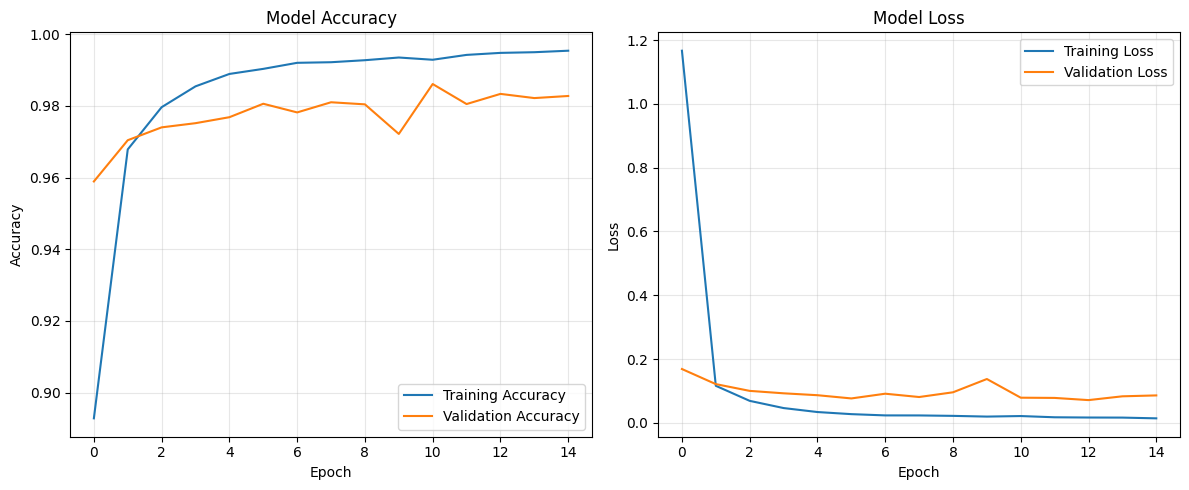

In [32]:
# TODO: Create accuracy plot (training vs validation accuracy over epochs)

plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
# TODO: Plot training and validation accuracy
plt.plot(history_best.history['accuracy'], label='Training Accuracy')
plt.plot(history_best.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Loss plot
plt.subplot(1, 2, 2)
# TODO: Plot training and validation loss
plt.plot(history_best.history['loss'], label='Training Loss')
plt.plot(history_best.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Step 6: Compare Against Feedforward Network

In [33]:
# Prepare data for feedforward network (flatten images)
X_train_flat = X_train.reshape(-1, 784).astype('float32') / 255.0
X_test_flat = X_test.reshape(-1, 784).astype('float32') / 255.0

print(f"Flattened training data shape: {X_train_flat.shape}")
print(f"Flattened test data shape: {X_test_flat.shape}")

Flattened training data shape: (60000, 784)
Flattened test data shape: (10000, 784)


In [34]:
# TODO: Build feedforward network
# Architecture:
# - Input: 784 features (flattened 28x28 image)
# - Dense layer: 128 nodes, ReLU activation
# - Dense layer: 64 nodes, ReLU activation
# - Output layer: 10 nodes, softmax activation

feedforward_nn = keras.Sequential([
    # TODO: Add layers here
    keras.layers.Flatten(input_shape=(28, 28, 1)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

# TODO: Compile the model
feedforward_nn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

feedforward_nn.summary()

c:\Users\dddva\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_15 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
# Record training time
print("Training feedforward network...")
start_time = time.time()

# TODO: Train feedforward network for 10 epochs
# Fit the model
feedforward_history = feedforward_nn.fit(
    X_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

# Record training time
feedforward_time = time.time() - start_time

# TODO: Evaluate on test set

test_loss, test_accuracy_ff = feedforward_nn.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy_ff:.4f}")
print(f"Test Loss: {test_loss:.4f}")

Training feedforward network...
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8399 - loss: 3.3896 - val_accuracy: 0.9014 - val_loss: 0.7940
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9211 - loss: 0.5490 - val_accuracy: 0.9179 - val_loss: 0.5235
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9396 - loss: 0.3155 - val_accuracy: 0.9334 - val_loss: 0.4090
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9526 - loss: 0.2137 - val_accuracy: 0.9401 - val_loss: 0.3571
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9614 - loss: 0.1559 - val_accuracy: 0.9445 - val_loss: 0.3192
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9658 - loss: 0.1351 - val_accuracy: 0.9477 - val_loss: 0.3112
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9708 - loss: 0.1098 - val_accuracy: 0.9484 - val_loss: 0.3058
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9712 -

In [36]:
# TODO: Create comparison table

comparison_data = {
    'Model': ['Baseline CNN', 'Best CNN', 'Feedforward NN'],
    'Architecture': [
        # TODO: Fill in architecture details
        'filters (32, 64), 3×3 kernel sizes',
        'FEWER filters (16, 32), 3×3 kernel sizes',
        'flattened 28x28 image'
    ],
    'Test Accuracy': [
        # TODO: Fill in test accuracies
        baseline_test_acc,
        test_accuracy_best,
        test_accuracy_ff
    ],
    'Training Time (s)': [
        # TODO: Fill in training times
        baseline_time,
        best_cnn_time,
        feedforward_time
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)


MODEL COMPARISON
         Model                             Architecture  Test Accuracy  Training Time (s)
  Baseline CNN       filters (32, 64), 3×3 kernel sizes         0.9877         148.936199
      Best CNN FEWER filters (16, 32), 3×3 kernel sizes         0.9850          77.213481
Feedforward NN                    flattened 28x28 image         0.9522          20.083024


### Analysis: CNN vs Feedforward Network

**TODO: Write 2-3 sentences answering:**
- How does your best CNN compare to the feedforward network on image data?
- Why does the CNN's spatial awareness lead to better performance than treating pixels as independent features?

My selected best CNN (FEWER filters (16, 32), 3×3 kernel sizes) outperformed the feedforward network on the image data, achieving 0.9850 test accuracy compared with 0.9522 for the feedforward model, although the feedforward network trained much faster at about 20.08 seconds versus 77.21 seconds for the best CNN. This happens because a CNN preserves the spatial structure of the image and learns local patterns such as edges, curves, and stroke combinations, whereas a feedforward network treats the image more like a long list of unrelated pixel values and therefore loses important positional information. The learning curves also suggest the best CNN learned effectively but began to show mild overfitting after roughly epoch 10 or 11, since training accuracy kept rising while validation performance stopped improving consistently.

---
## Step 7: Reflect on Specialized Architectures for Your Final Project

### Final Project Application

**TODO: Write 3-4 sentences answering:**
- Based on your Unit 9 final project proposal, would CNNs or RNNs enhance your project? Why or why not?
- If your project uses tabular data (customer demographics, transaction records), explain why feedforward networks or traditional ML models remain appropriate.
- If your project could benefit from specialized architectures (images, time series, text), describe specifically how CNNs or RNNs would improve your solution compared to the approaches you've planned.

My Unit 9 final project proposal is based on the US-Accidents: A Countrywide Traffic Accident Dataset, a large tabular dataset containing about 1.5 million accident records collected across 49 U.S. states from February 2016 onward. Because this project is centered mainly on structured variables such as time, location, weather, road conditions, and accident attributes, more traditional machine learning models like decision trees and random forests are more appropriate than CNNs or RNNs for the core analysis. CNNs are most useful when the input has strong spatial structure such as images, and RNNs are most useful when the main problem depends on ordered sequences over time, so neither is automatically the best choice for a standard tabular accident-prediction task. However, if I become more advanced in my capabilites in future years I could maybe extend the project to include traffic camera images, map-based spatial grids, or time-ordered forecasting of accident patterns, then CNNs or RNNs could improve the solution by capturing visual or temporal relationships that ordinary tabular models would miss - but that will be out of scope for my project this semester.


---
## Submission Checklist

Before submitting, ensure you have:
- [ ] Built and trained baseline CNN (2 conv layers)
- [ ] Conducted at least 3 architecture experiments (filter counts and kernel sizes)
- [ ] Trained best CNN architecture for 15 epochs
- [ ] Created accuracy and loss plots for best model
- [ ] Built and trained feedforward network for comparison
- [ ] Created comparison table with all models
- [ ] Answered all analysis questions in Markdown cells
- [ ] Written reflection on final project application
- [ ] Pushed code to GitHub repository
- [ ] Submitted GitHub repository link to assignment

---
## Step 8: Submit Your Work
Push to GitHub:
```bash
git add .
git commit -m 'completed CNN architecture assignment'
git push
```

Submit your GitHub repository link on the course platform.